In [ ]:
# --- Colab setup (auto-inserted; no-op outside Colab). tag: colab-bootstrap ---
import sys
if "google.colab" in sys.modules:
    import os, subprocess, pathlib
    _slug = "aniryou/full-stack-agentic-engineer"
    _root = pathlib.Path("/content") / "full-stack-agentic-engineer"
    if not _root.exists():
        subprocess.run(["git", "clone", "--depth", "1", f"https://github.com/{_slug}.git", str(_root)], check=True)
    os.chdir(_root / "07-application-agent-framework/retrieval-rag/embeddings-lab/notebooks")
    for _c in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (_c / "pyproject.toml").exists() or (_c / "setup.py").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(_c)]); break
        if (_c / "requirements.txt").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(_c / "requirements.txt")]); break
        if _c == _root:
            break
    if str(pathlib.Path.cwd()) not in sys.path:
        sys.path.insert(0, str(pathlib.Path.cwd()))


# 02 · A contrastive bi-encoder from scratch
**One idea:** InfoNCE with in-batch negatives is what turns "a representation"
into "an embedding model". We train a linear encoder on Contriever-style crop
pairs (two halves of the same paragraph = a positive pair), with manual
gradients, and watch **alignment & uniformity** do their thing. *Primer §4.*

In [1]:
import numpy as np, matplotlib.pyplot as plt
from collections import Counter
rng = np.random.default_rng(1)

paras = [l.split() for l in open("../data/tiny_corpus.txt")]
counts = Counter(w for p in paras for w in p)
vocab = sorted(w for w, c in counts.items() if c >= 5)
w2i = {w: i for i, w in enumerate(vocab)}
V = len(vocab)

TOPIC_WORDS = {  # for coloring plots only — the model never sees these labels
    "people": {"king","queen","prince","princess","man","woman","boy","girl"},
    "animals": {"dog","cat","horse","cow","sheep","bird","fish","goat"},
    "food": {"bread","cheese","soup","rice","tea","coffee","honey","stew"},
    "tools": {"hammer","saw","rope","wheel","plough","anvil","ladder","chisel"},
    "weather": {"rain","snow","wind","storm","cloud","frost","mist"},
}
def topic_of(toks):
    hits = {t: len(set(toks) & ws) for t, ws in TOPIC_WORDS.items()}
    return max(hits, key=hits.get)

def bow(toks):
    x = np.zeros(V)
    for t in toks:
        if t in w2i:
            x[w2i[t]] = 1.0
    return x

# positive pair = independent crops: first half vs second half of a paragraph
A = np.stack([bow(p[: len(p) // 2]) for p in paras])
Bx = np.stack([bow(p[len(p) // 2 :]) for p in paras])
topics = np.array([topic_of(p) for p in paras])
A_tr, B_tr = A[:5000], Bx[:5000]
A_te, B_te = A[5000:], Bx[5000:]
print(f"train pairs {len(A_tr)}, test pairs {len(A_te)}, feature dim {V}")

train pairs 5000, test pairs 1000, feature dim 127


## Encoder + symmetric InfoNCE, gradients by hand
`E(x) = l2norm(x @ W)`, similarity matrix `S = Z_a Z_bᵀ / τ`. The loss is
cross-entropy toward the diagonal, in both directions. The gradient of
softmax-CE w.r.t. `S` is just `(softmax − I)/B`, then chain through the
l2-normalization: for `z = u/‖u‖`, `du = (dz − z(z·dz))/‖u‖`.

epoch 0  loss 2.033
epoch 1  loss 1.957
epoch 2  loss 1.938
epoch 3  loss 1.929
epoch 4  loss 1.899
epoch 5  loss 1.922
epoch 6  loss 1.911
epoch 7  loss 1.905


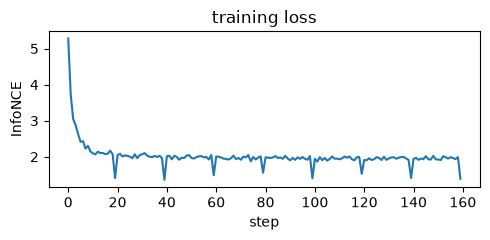

In [2]:
def encode(X, W):
    Uu = X @ W
    n = np.linalg.norm(Uu, axis=1, keepdims=True) + 1e-9
    return Uu / n, Uu, n

def softmax(S, axis):
    e = np.exp(S - S.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def info_nce(Za, Zb, tau):
    Bn = len(Za)
    S = Za @ Zb.T / tau
    Pr, Pc = softmax(S, 1), softmax(S, 0)
    idx = np.arange(Bn)
    loss = -0.5 * (np.log(Pr[idx, idx] + 1e-12).mean()
                   + np.log(Pc[idx, idx] + 1e-12).mean())
    I = np.eye(Bn)
    dS = 0.5 * ((Pr - I) + (Pc - I)) / Bn
    return loss, dS @ Zb / tau, dS.T @ Za / tau   # loss, dZa, dZb

def back_norm(dZ, Z, n):
    return (dZ - Z * (Z * dZ).sum(1, keepdims=True)) / n

def train(tau=0.05, dim=32, epochs=8, Bsz=256, lr=0.02, seed=2, log=True):
    r = np.random.default_rng(seed)
    W = r.normal(0, 0.1, (V, dim))
    m, v2, t = np.zeros_like(W), np.zeros_like(W), 0        # Adam
    hist = []
    for ep in range(epochs):
        perm = r.permutation(len(A_tr))
        for s in range(0, len(A_tr), Bsz):
            i = perm[s : s + Bsz]
            Za, Ua, na = encode(A_tr[i], W)
            Zb, Ub, nb = encode(B_tr[i], W)
            loss, dZa, dZb = info_nce(Za, Zb, tau)
            dW = A_tr[i].T @ back_norm(dZa, Za, na) + B_tr[i].T @ back_norm(dZb, Zb, nb)
            t += 1
            m = 0.9 * m + 0.1 * dW
            v2 = 0.999 * v2 + 0.001 * dW ** 2
            W -= lr * (m / (1 - 0.9**t)) / (np.sqrt(v2 / (1 - 0.999**t)) + 1e-8)
            hist.append(loss)
        if log:
            print(f"epoch {ep}  loss {np.mean(hist[-10:]):.3f}")
    return W, hist

W, hist = train()
plt.figure(figsize=(5, 2.5)); plt.plot(hist); plt.xlabel("step"); plt.ylabel("InfoNCE")
plt.title("training loss"); plt.tight_layout(); plt.show()

## Evaluation: retrieve the paired half among 1000 candidates

In [3]:
def recall_at(Za, Zb, ks=(1, 5)):
    S = Za @ Zb.T
    ranks = (S > S[np.arange(len(S)), np.arange(len(S))][:, None]).sum(1)
    return {k: float((ranks < k).mean()) for k in ks}

Za_te, *_ = encode(A_te, W)
Zb_te, *_ = encode(B_te, W)
Wr = np.random.default_rng(3).normal(0, 0.1, (V, 32))
Zar, *_ = encode(A_te, Wr); Zbr, *_ = encode(B_te, Wr)
Abow = A_te / (np.linalg.norm(A_te, axis=1, keepdims=True) + 1e-9)
Bbow = B_te / (np.linalg.norm(B_te, axis=1, keepdims=True) + 1e-9)

print("random 32-d encoder :", recall_at(Zar, Zbr))
print(f"raw BoW cosine {V}-d:", recall_at(Abow, Bbow))
print("trained 32-d encoder:", recall_at(Za_te, Zb_te))

random 32-d encoder : {1: 0.032, 5: 0.101}
raw BoW cosine 127-d: {1: 0.043, 5: 0.135}
trained 32-d encoder: {1: 0.062, 5: 0.248}


## What training did to the geometry: alignment ↓, uniformity held
Wang & Isola (2020): contrastive loss = pull positives together (*alignment*,
lower is better) while spreading everything on the sphere (*uniformity*, lower
is better). Training buys a ~10× alignment gain at almost no uniformity cost.
The failure mode to watch in your own fine-tunes is collapse: alignment AND
uniformity both near 0 means everything mapped to one point.

In [4]:
def alignment(Za, Zb):
    return float((np.linalg.norm(Za - Zb, axis=1) ** 2).mean())

def uniformity(Z, m=2000, seed=0):
    r = np.random.default_rng(seed)
    i, j = r.integers(0, len(Z), m), r.integers(0, len(Z), m)
    keep = i != j
    d2 = np.linalg.norm(Z[i[keep]] - Z[j[keep]], axis=1) ** 2
    return float(np.log(np.exp(-2 * d2).mean()))

for name, (Xa, Xb) in {"random enc": (Zar, Zbr), "raw BoW": (Abow, Bbow),
                       "trained": (Za_te, Zb_te)}.items():
    print(f"{name:>10}: alignment {alignment(Xa, Xb):5.2f}   uniformity {uniformity(Xa):6.2f}")

random enc: alignment  0.87   uniformity  -2.45
   raw BoW: alignment  0.88   uniformity  -2.64
   trained: alignment  0.08   uniformity  -2.32


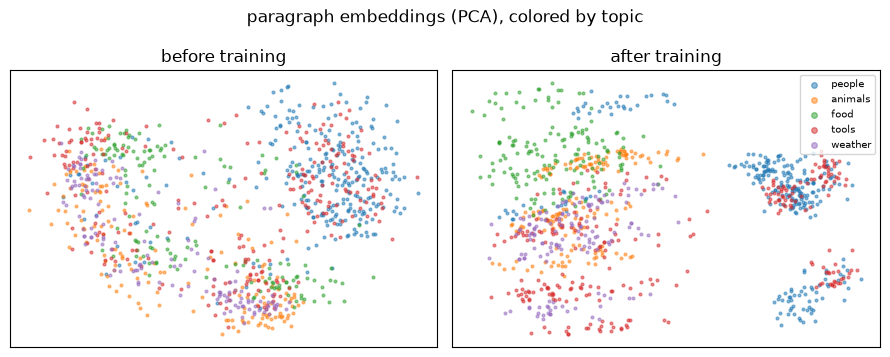

In [5]:
def pca2(Z):
    Zc = Z - Z.mean(0)
    _, _, Vt = np.linalg.svd(Zc, full_matrices=False)
    return Zc @ Vt[:2].T

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, Z, title in [(axes[0], Zar, "before training"), (axes[1], Za_te, "after training")]:
    P2 = pca2(Z)
    for t in TOPIC_WORDS:
        sel = topics[5000:] == t
        ax.scatter(P2[sel, 0], P2[sel, 1], s=4, alpha=0.5, label=t)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(markerscale=2, fontsize=7)
plt.suptitle("paragraph embeddings (PCA), colored by topic")
plt.tight_layout(); plt.show()

## Temperature: the sharpness knob
Small τ focuses the softmax on the hardest negatives; too small is unstable,
too large under-trains. This is why every model card lists τ ≈ 0.02–0.05.

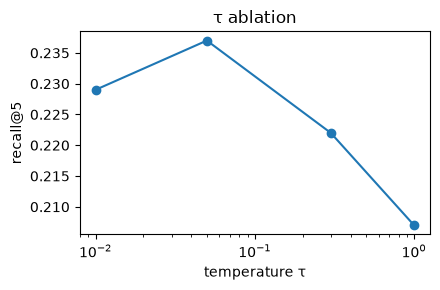

{1.0: 0.207, 0.3: 0.222, 0.05: 0.237, 0.01: 0.229}


In [6]:
taus, recs = [1.0, 0.3, 0.05, 0.01], []
for tau in taus:
    Wt, _ = train(tau=tau, epochs=4, log=False)
    Za, *_ = encode(A_te, Wt); Zb, *_ = encode(B_te, Wt)
    recs.append(recall_at(Za, Zb)[5])
plt.figure(figsize=(4.5, 3))
plt.semilogx(taus, recs, "o-")
plt.xlabel("temperature τ"); plt.ylabel("recall@5"); plt.title("τ ablation")
plt.tight_layout(); plt.show()
print(dict(zip(taus, [round(r, 3) for r in recs])))

**Takeaways.** (1) The entire modern recipe — E5, BGE, CLIP — is this loop with
bigger encoders and more pairs. (2) In-batch negatives make batch size a quality
knob. (3) Alignment/uniformity are cheap diagnostics for your own fine-tunes.
→ Exercises: `exercises/ex02.ipynb` (implement the loss+grad, mine hard
negatives, and a Matryoshka variant).